# EDA on Subject One

We are focusing on analysing subject one and creating a baseline model

In [1]:
%load_ext autoreload
%autoreload 2

# Imports / インポート

This cell imports all libraries and utility functions used throughout this notebook.
These include data loading, preprocessing, visualization, feature analysis, and plotting libraries.

このセルでは、このノートブック全体で使用するライブラリおよびユーティリティ関数を読み込みます。
データ読み込み、前処理、可視化、特徴量分析、およびグラフ描画に必要なモジュールをインポートします。

In [ ]:
# Load subject datasets.
# 被験者データを読み込むための関数。
from har_utils.data import get_subject

# List of available subject IDs.
# 利用可能な被験者IDの一覧。
from har_utils.config import FILE_NAME_SUFFIX

# Visualization helper functions.
# 可視化用のヘルパー関数。
import har_utils.visualization as viz

# Preprocessing pipeline and utility functions.
# 前処理パイプラインおよび関連ユーティリティ。
from har_utils.preprocessing import (
    do_sanity_check, 
    preprocessing_pipeline,
    get_shoulder_width,
    drop_bad_frames
)

from har_utils.analysis import compare_feature_description

from har_utils.model import model_random_forest


# Plotting libraries.
# グラフ描画ライブラリ。
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import joblib


In [4]:
# Load the first subject's dataset for initial exploration.
# 最初の被験者データを読み込み、内容を確認する。
all_subjects = {}
subject1_key = FILE_NAME_SUFFIX[0]
all_subjects[subject1_key] = get_subject(subject1_key) 

print(all_subjects[subject1_key].shape)
all_subjects[subject1_key].head()

(76456, 35)


,nose_x,nose_y,left_eye_x,left_eye_y,right_eye_x,right_eye_y,left_ear_x,left_ear_y,right_ear_x,right_ear_y,...,right_hip_y,left_knee_x,left_knee_y,right_knee_x,right_knee_y,left_ankle_x,left_ankle_y,right_ankle_x,right_ankle_y,Action Label
frame_id,,,,,,,,,,,,,,,,,,,,,
0,624.0,258.25,628.0,249.50,625.0,249.750,650.5,252.250,667.5,249.125,...,441.00,656.5,535.0,724.0,528.0,634.5,616.5,746.5,612.0,Walking
1,618.0,260.00,621.5,251.25,618.5,251.625,644.0,254.375,660.5,251.125,...,440.00,651.0,533.5,720.0,526.5,627.5,616.0,746.0,610.5,Walking
2,611.5,260.50,615.0,252.00,613.0,252.250,637.0,256.000,656.5,252.625,...,441.00,644.5,533.0,715.5,525.5,625.5,616.5,746.0,609.5,Walking
3,604.0,261.00,608.0,252.50,605.5,252.750,630.5,256.000,648.5,252.875,...,443.00,639.0,535.0,710.5,525.5,623.0,618.0,745.5,608.0,Walking
4,598.0,260.00,602.5,252.00,600.0,252.000,623.0,256.750,642.5,253.125,...,444.25,634.5,539.0,703.0,525.5,620.5,619.0,742.5,605.5,Walking


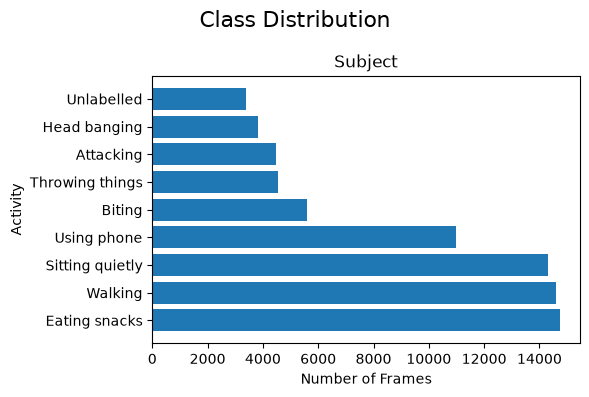

In [5]:
# Visualize the activity distribution for Subject 1.
# Subject 1 のアクティビティ分布を棒グラフで可視化する。
viz.plot_class_distribution(all_subjects[subject1_key])

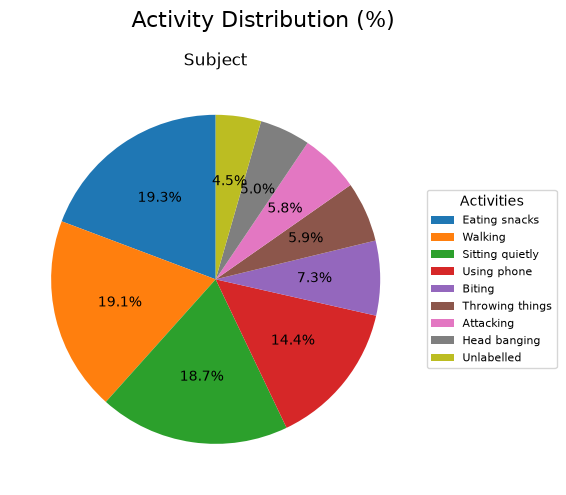

In [6]:
# Visualize the percentage distribution of activities for Subject 1.
# Subject 1 のアクティビティ割合を円グラフで可視化する。
viz.plot_percentage_distribution(all_subjects[subject1_key])

In [7]:
# Perform a sanity check on the subject datasets before preprocessing.
# 前処理を行う前に、すべての被験者データの整合性を確認する。
sanity_summary = do_sanity_check(all_subjects)

display(sanity_summary)

,Subject,Rows,Columns,NaN Count,Inf Count,Rows with NaN,Rows with Inf,Duplicate Rows
0,1,76456,35,3406,0,3406,0,3


## Skeleton Normalization Pipeline / スケルトン正規化パイプライン

This stage preprocesses the raw pose keypoints and produces normalized skeleton coordinates. The following operations are performed:

1. Remove rows with missing activity labels.
2. Standardize activity labels for consistency.
3. Translate each skeleton so that the hip center becomes the origin.
4. Normalize body size by scaling all joint coordinates using the torso height. This approach was adopted instead of shoulder-width normalization to provide more stable scaling across different poses.
5. *(Optional)* Remove unreliable frames with abnormally small shoulder widths before further feature extraction.

---

## スケルトン正規化パイプライン

この段階では、生の姿勢キーポイントを前処理し、正規化されたスケルトン座標を生成する。以下の処理を実行する。

1. アクティビティラベルが欠損している行を削除する。
2. アクティビティラベルを統一し、表記ゆれを解消する。
3. 腰中心（Hip Center）が原点となるように各スケルトンを平行移動する。
4. 全関節座標を胴体長（Torso Height）でスケーリングし、被験者間の体格差を正規化する。なお、肩幅による正規化ではなく、より安定したスケーリングが可能な胴体長を採用した。
5. （任意）肩幅が異常に小さい信頼性の低いフレームを除外する。

In [8]:
# Apply the complete preprocessing pipeline to Subject 1.
# Subject 1 に前処理パイプラインを適用し、学習用特徴量を生成する。
all_subjects_norm = {}
all_subjects_norm[subject1_key] = preprocessing_pipeline(all_subjects[subject1_key], return_stage='normalized')

## Skeleton Normalization Comparison / スケルトン正規化の比較

The following visualization compares a pose coordinate before and after skeleton normalization. This helps verify that the normalization removes the effects of body position and scale while preserving the underlying movement pattern.

以下の可視化では、スケルトン正規化の前後で姿勢座標を比較します。これにより、身体の位置や大きさの影響が除去され、動作パターンが維持されていることを確認できます。

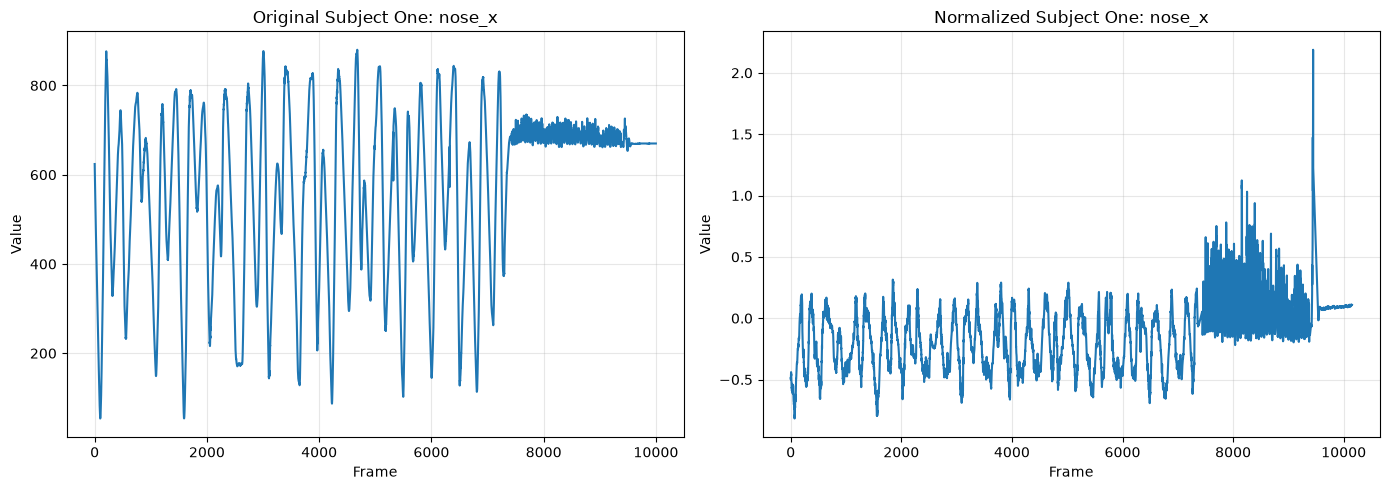

In [9]:
viz.plot_compare_feature_side_by_side(
    all_subjects[subject1_key],
    all_subjects_norm[subject1_key],
    "nose_x",
    "Subject One",
    start=0,
    end=10000)

## Feature Distribution Before and After Normalization / 正規化前後の特徴量分布

The following histograms compare the distribution of a feature before and after skeleton normalization. The original coordinates are represented in image space, whereas the normalized coordinates are expressed relative to the subject's body.

以下のヒストグラムでは、スケルトン正規化前後の特徴量分布を比較します。正規化前は画像座標、正規化後は身体を基準とした相対座標で表現されています。

**Conclusion / 結論**

- Feature values become centered around zero after normalization.
- The range of values is significantly reduced.
- Subject-specific variations caused by body size and camera position are minimized.

- 正規化後の特徴量は0付近を中心とした分布になります。
- 特徴量の値の範囲が大幅に縮小されます。
- 体格やカメラ位置による被験者間のばらつきが低減されます。

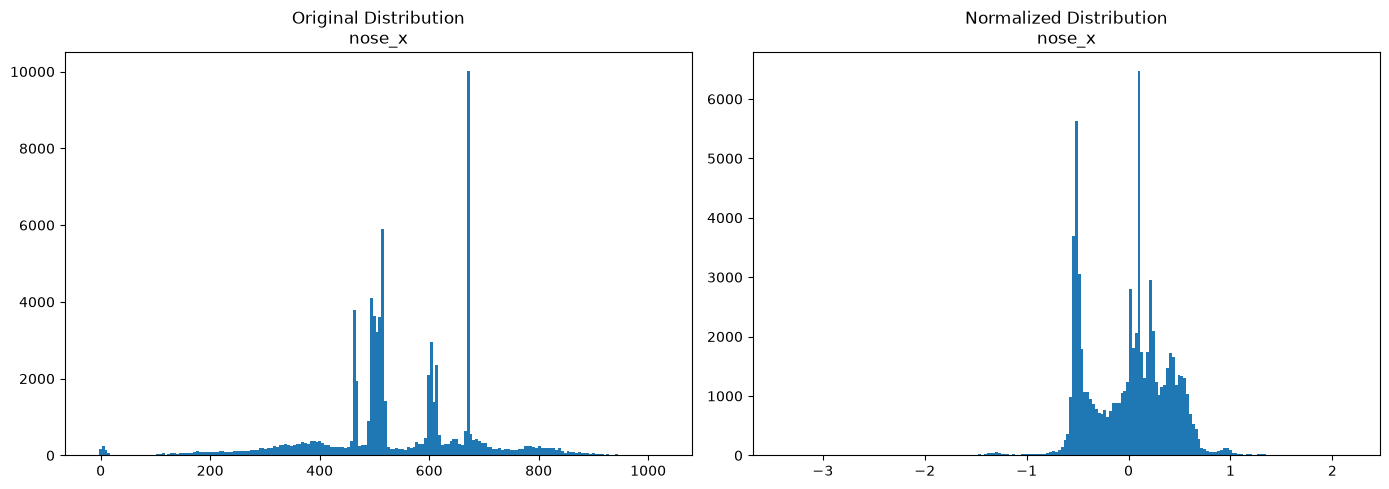

In [10]:
# Compare the feature distributions before and after skeleton normalization.
# スケルトン正規化前後の特徴量分布を比較する。

viz.plot_compare_histograms(
    all_subjects[subject1_key],
    all_subjects_norm[subject1_key],
    "nose_x",
    bins=200
)

## Feature Statistics Before and After Normalization / 正規化前後の特徴量統計

The descriptive statistics below compare the `nose_x` feature before and after skeleton normalization. This provides a quantitative view of how the transformation affects the feature distribution.

以下の要約統計量では、スケルトン正規化前後の `nose_x` 特徴量を比較しています。正規化による特徴量分布の変化を定量的に確認できます。

**Key Observations / 主な観察結果**

- The mean shifts from **542.46** to **-0.01**, indicating that the coordinates are centered around the body origin after normalization.
- The standard deviation decreases from **145.67** to **1.05**, showing a substantial reduction in feature variability.
- The interquartile range (25%-75%) becomes much narrower, indicating a more consistent distribution across frames.
- The feature values are expressed in body-relative units rather than image pixels, making them less dependent on body size and camera position.

- 平均値は **542.46** から **-0.01** に変化しており、正規化後は身体中心を基準とした座標になっていることが分かります。
- 標準偏差は **145.67** から **1.05** に減少しており、特徴量のばらつきが大幅に低減されています。
- 四分位範囲（25%～75%）も狭くなっており、より一貫した分布になっています。
- 特徴量は画像座標ではなく身体基準の相対座標となり、体格やカメラ位置の影響を受けにくくなっています。

In [11]:
compare_feature_description(all_subjects[subject1_key], all_subjects_norm[subject1_key], "nose_x")

Original
count    76456.000000
mean       542.463043
std        145.670475
min        -13.562500
25%        485.000000
50%        515.000000
75%        664.500000
max       1028.000000
Name: nose_x, dtype: float64

Normalized
count    73050.000000
mean        -0.003477
std          0.400525
min         -3.407941
25%         -0.405793
50%          0.078305
75%          0.268111
max          2.187877
Name: nose_x, dtype: float64


## Shoulder Width Analysis / 肩幅の分析

This analysis is retained for documentation purposes to explain an earlier design decision in the preprocessing pipeline.

この分析は、前処理パイプラインにおける初期設計の判断を記録するために残しています。

**Reasoning / 理由**

- Initially, shoulder width was used as the normalization scale.
- When the shoulder width became very small (approaching zero), the normalization factor also became very small.
- As a result, the normalized coordinates became excessively large, introducing outliers and distorting statistical features such as the mean and standard deviation.
- Therefore, frames with abnormally small shoulder widths were removed before normalization.

- 当初は肩幅を正規化の基準として使用していました。
- 肩幅が非常に小さくなると、正規化係数も極めて小さくなります。
- その結果、正規化後の座標が異常に大きくなり、平均や標準偏差などの統計特徴量に悪影響を与える外れ値が発生しました。
- そのため、肩幅が異常に小さいフレームを正規化前に除外していました。

**Current Implementation / 現在の実装**

- The current preprocessing pipeline uses **torso length** as the normalization scale instead of shoulder width.
- The shoulder width analysis is retained for reference and to document the rationale behind the frame filtering step.

- 現在の前処理パイプラインでは、正規化の基準として肩幅ではなく**胴体長（torso length）**を使用しています。
- この肩幅の分析は、フレーム除外の根拠を示すための参考資料および設計履歴として残しています。

In [12]:
# Analyze the shoulder width distribution to determine a filtering threshold.
# フィルタリングしきい値を決めるため、肩幅の分布を確認する。

shoulder_width = get_shoulder_width(all_subjects[subject1_key])
print(shoulder_width.describe())

count    76456.000000
mean        53.050572
std         21.223071
min          0.500000
25%         42.735378
50%         51.924224
75%         59.588694
max        210.690086
dtype: float64


In [13]:
# Inspect the smallest 20 shoulder widths to help determine a filtering threshold.
# フィルタリングしきい値の決定に向けて、最小の肩幅を確認する。

print(shoulder_width.nsmallest(20))

frame_id
37907    0.500000
58585    0.515388
27276    0.559017
37908    0.559017
75400    0.559017
58875    0.625000
58874    0.750000
37906    0.901388
76423    1.000000
37905    1.118034
66729    1.147347
19562    1.231107
74291    1.238250
66730    1.274755
74290    1.397215
27277    1.520691
6326     1.546165
74289    1.558922
58583    1.581139
19626    1.625000
dtype: float64


In [14]:
# Summarize the impact of the selected shoulder-width threshold.
# 選択した肩幅しきい値の影響を確認する。

n_bad_frames = (shoulder_width < 10).sum()
bad_frame_percentage = (n_bad_frames / len(shoulder_width)) * 100

print(f"Frames with shoulder width < 10: {n_bad_frames}")
print(f"Percentage of frames removed: {bad_frame_percentage:.2f}%")

Frames with shoulder width < 10: 1522
Percentage of frames removed: 1.99%


In [15]:
# Calculate the percentage of low-quality frames for each activity.
# 各アクティビティにおける低品質フレームの割合を計算する。

bad_frames = shoulder_width < 10
bad_counts = all_subjects[subject1_key].loc[bad_frames, 'Action Label'].value_counts()
total_counts = all_subjects[subject1_key]['Action Label'].value_counts()
bad_ratio = (
    bad_counts / total_counts * 100
).sort_values(ascending=False)

print(bad_ratio)

Action Label
Attacking          7.225951
Walking            6.084873
Throwing things    3.377483
Using phone        0.109290
Biting                  NaN
Eating snacks           NaN
Head banging            NaN
Sitting quietly         NaN
Name: count, dtype: float64


In [16]:
# Inspect the largest normalized coordinate values to identify potential outliers.
# 正規化後の座標の最大値を確認し、外れ値の有無を調査する。

all_subjects_norm[subject1_key]['nose_x'].abs().sort_values(ascending=False).head(20)

frame_id
25730    3.407941
9447     2.187877
9446     2.003175
9445     1.865631
9448     1.840567
27058    1.829647
27055    1.824298
25732    1.812058
27056    1.793271
27072    1.781294
27059    1.771519
27060    1.771456
25731    1.766085
27057    1.759815
27054    1.758287
27074    1.740315
27053    1.730871
27073    1.702015
27052    1.673385
27075    1.603171
Name: nose_x, dtype: float64

In [17]:
all_subjects_norm[subject1_key].describe()

,nose_x,nose_y,left_eye_x,left_eye_y,right_eye_x,right_eye_y,left_ear_x,left_ear_y,right_ear_x,right_ear_y,...,right_hip_x,right_hip_y,left_knee_x,left_knee_y,right_knee_x,right_knee_y,left_ankle_x,left_ankle_y,right_ankle_x,right_ankle_y
count,73050.000000,73050.000000,73050.000000,73050.000000,73050.000000,73050.000000,73050.000000,73050.000000,73050.000000,73050.000000,...,73050.000000,73050.000000,73050.000000,73050.000000,73050.000000,73050.000000,73050.000000,73050.000000,73050.000000,73050.000000
mean,-0.003477,-1.278986,0.008784,-1.372408,-0.083490,-1.338071,-0.041449,-1.399764,-0.263078,-1.303586,...,-0.111928,0.101409,0.607581,0.046041,0.377567,0.415468,0.715221,0.610788,0.603469,0.755643
std,0.400525,0.244536,0.404481,0.245651,0.399897,0.247984,0.363830,0.211787,0.362519,0.225384,...,0.129101,0.081499,0.429506,0.496014,0.373492,0.284205,0.644230,0.543251,0.628704,0.464135
min,-3.407941,-1.621094,-2.788316,-1.704430,-3.769390,-1.620048,-2.072244,-1.769765,-3.769390,-1.529013,...,-2.788316,-0.335631,-1.674122,-0.942414,-4.027567,-0.582160,-1.546378,-0.419929,-2.168690,-0.385497
25%,-0.405793,-1.410120,-0.363636,-1.500751,-0.429947,-1.468621,-0.285130,-1.518346,-0.391621,-1.426293,...,-0.189652,0.024483,0.215225,-0.441707,0.063913,0.267427,0.289175,0.125485,0.137075,0.376902
50%,0.078305,-1.360075,0.094879,-1.462260,-0.046761,-1.434283,0.016683,-1.455754,-0.217257,-1.401039,...,-0.141323,0.087586,0.725934,-0.049078,0.388045,0.476327,0.548355,0.468411,0.541131,0.655122
75%,0.268111,-1.282354,0.269685,-1.361506,0.214553,-1.345883,0.247286,-1.367712,-0.033087,-1.331602,...,-0.089102,0.174661,0.933819,0.595313,0.767659,0.630750,0.890433,1.146418,0.728822,1.188427
max,2.187877,3.473845,2.383541,3.325159,1.956638,3.244058,2.823584,2.338425,1.338799,1.892367,...,1.225100,0.301644,5.524996,8.364947,1.543753,7.824959,4.821065,13.709219,1.928902,14.948470


In [18]:
# Remove frames with abnormally small shoulder widths and inspect the cleaned dataset.
# 肩幅が異常に小さいフレームを除外し、クリーニング後のデータセットを確認する。

all_subjects_norm[subject1_key] = drop_bad_frames(all_subjects[subject1_key], all_subjects_norm[subject1_key])
all_subjects_norm[subject1_key].describe()

,nose_x,nose_y,left_eye_x,left_eye_y,right_eye_x,right_eye_y,left_ear_x,left_ear_y,right_ear_x,right_ear_y,...,right_hip_x,right_hip_y,left_knee_x,left_knee_y,right_knee_x,right_knee_y,left_ankle_x,left_ankle_y,right_ankle_x,right_ankle_y
count,71673.000000,71673.000000,71673.000000,71673.000000,71673.000000,71673.000000,71673.000000,71673.000000,71673.000000,71673.000000,...,71673.000000,71673.000000,71673.000000,71673.000000,71673.000000,71673.000000,71673.000000,71673.000000,71673.000000,71673.000000
mean,-0.001046,-1.277610,0.011343,-1.371605,-0.081781,-1.336767,-0.039190,-1.400210,-0.264141,-1.302539,...,-0.114139,0.103255,0.617664,0.035158,0.382259,0.411640,0.726303,0.599159,0.611351,0.746775
std,0.401872,0.245986,0.406141,0.247273,0.401774,0.249515,0.366229,0.213285,0.365258,0.227004,...,0.129130,0.081131,0.426729,0.494254,0.374381,0.285083,0.644289,0.541334,0.629814,0.463227
min,-3.407941,-1.621094,-2.788316,-1.704430,-3.769390,-1.620048,-2.072244,-1.769765,-3.769390,-1.529013,...,-2.788316,-0.335631,-1.674122,-0.942414,-4.027567,-0.582160,-1.546378,-0.419929,-2.168690,-0.385497
25%,-0.405821,-1.410158,-0.364320,-1.501226,-0.432568,-1.468772,-0.292237,-1.519349,-0.403269,-1.426922,...,-0.190504,0.026879,0.227711,-0.445448,0.064390,0.266435,0.306322,0.123552,0.144214,0.376216
50%,0.082935,-1.359841,0.097830,-1.463220,-0.046509,-1.434497,0.021840,-1.458765,-0.219588,-1.401761,...,-0.146314,0.089923,0.732909,-0.049710,0.403393,0.470601,0.562952,0.462504,0.544006,0.639074
75%,0.276298,-1.276900,0.279590,-1.357290,0.224777,-1.340338,0.248191,-1.368311,-0.030535,-1.329250,...,-0.089730,0.175317,0.934903,0.590620,0.769537,0.628462,0.892330,1.134559,0.732486,1.176688
max,2.187877,3.473845,2.383541,3.325159,1.956638,3.244058,2.823584,2.338425,1.338799,1.892367,...,1.225100,0.301644,5.524996,8.364947,1.543753,7.824959,4.821065,13.709219,1.928902,14.948470


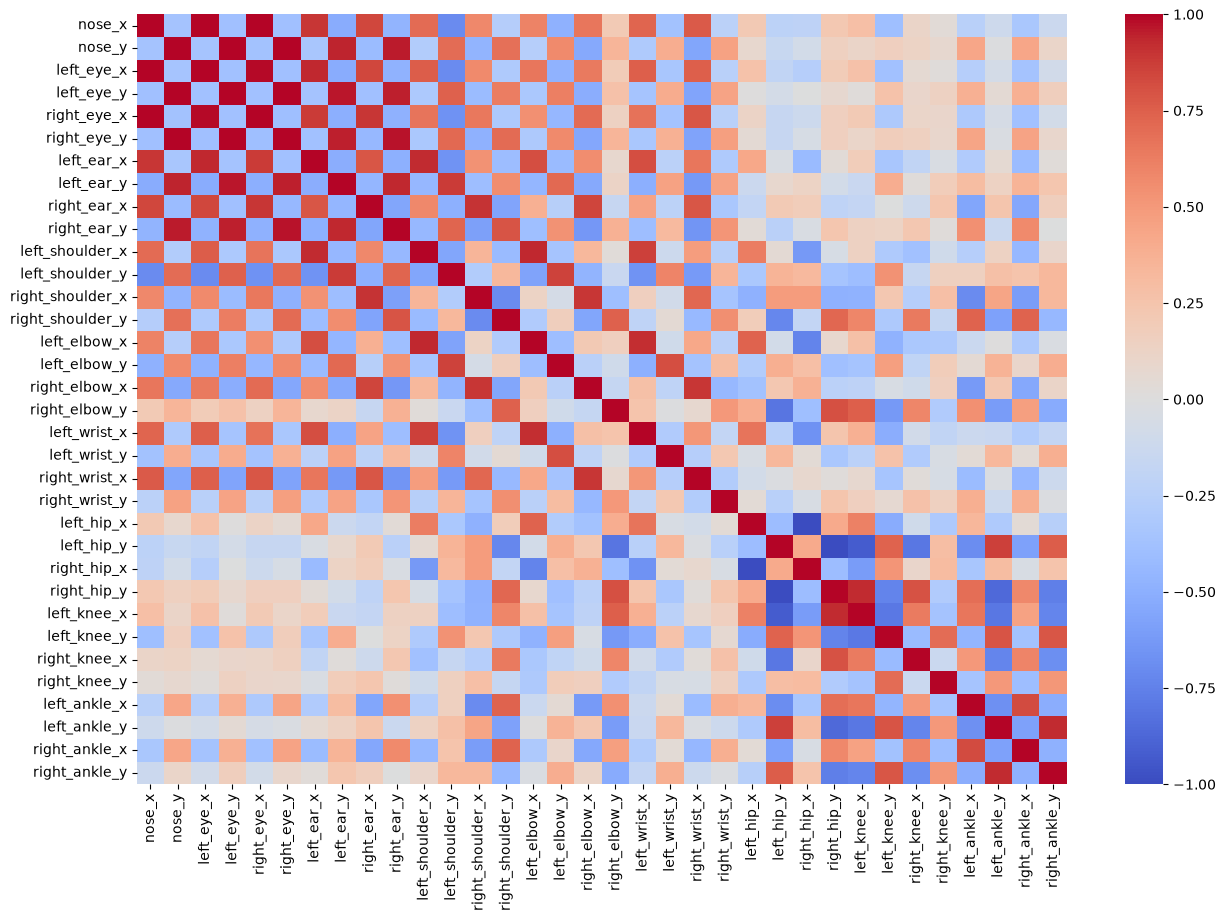

In [19]:
# Visualize the correlation matrix of all numerical features after frame filtering.
# 不良フレーム除外後の数値特徴量間の相関行列を可視化する。

plt.figure(figsize=(15,10))
sns.heatmap(
    all_subjects_norm[subject1_key].select_dtypes(include='number').corr(),
    cmap='coolwarm'
)
plt.show()

## Principal Component Analysis (PCA) / 主成分分析（PCA）

Principal Component Analysis (PCA) is performed to examine how much of the dataset's variance can be explained by a reduced number of principal components. Since PCA is sensitive to feature scale, all numerical features are standardized before the analysis.

主成分分析（PCA）を実施し、少数の主成分でデータ全体の分散をどの程度説明できるかを確認します。PCAは特徴量のスケールに影響を受けるため、解析前にすべての数値特徴量を標準化しています。

**Purpose / 目的**

- Evaluate the intrinsic dimensionality of the dataset.
- Determine whether dimensionality reduction could be beneficial.

- データセットの実質的な次元数を把握する。
- 次元削減が有効かどうかを判断する。

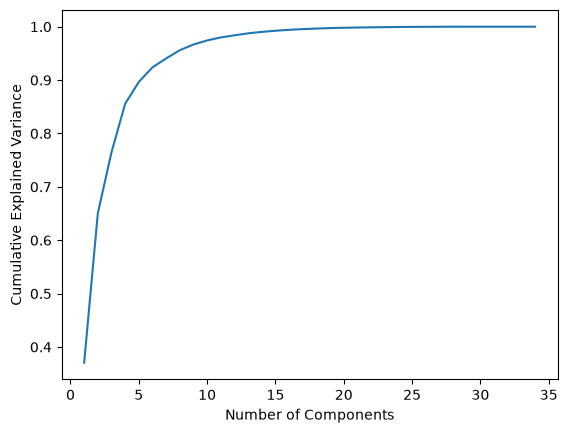

In [20]:
# Analyze the cumulative explained variance using PCA.
# PCAを用いて累積寄与率を分析する。

X = all_subjects_norm[subject1_key].drop(columns=['Action Label'])
X_scaled = StandardScaler().fit_transform(X)

pca = PCA()
pca.fit(X_scaled)

plt.plot(
    range(1, len(pca.explained_variance_ratio_)+1),
    pca.explained_variance_ratio_.cumsum()
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.show()


                    Evaluating Model: RandomForestClassifier                    

********************************************************************************
                             Classification Report                              
********************************************************************************
                 precision    recall  f1-score   support

      Attacking       0.99      0.95      0.97       829
         Biting       1.00      1.00      1.00      1122
  Eating snacks       1.00      1.00      1.00      2946
   Head banging       1.00      1.00      1.00       762
Sitting quietly       1.00      1.00      1.00      2862
Throwing things       0.99      1.00      0.99       876
    Using phone       1.00      1.00      1.00      2194
        Walking       0.98      1.00      0.99      2744

       accuracy                           1.00     14335
      macro avg       1.00      0.99      0.99     14335
   weighted avg       1.00      1.00      1.0

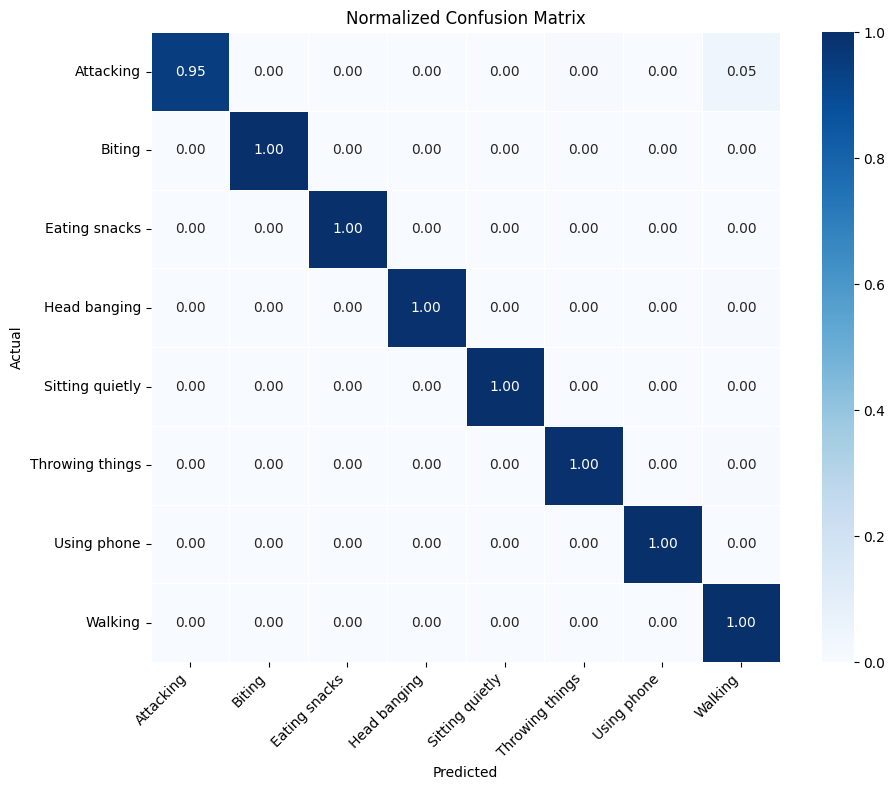

In [23]:
# Evaluate a Random Forest model using the preprocessed dataset.
# 前処理済みデータセットを用いて、ランダムフォレストモデルを評価する。
rf = model_random_forest()
evaluate_supervised(all_subjects_norm, rf);


                Evaluating Model: HistGradientBoostingClassifier                

********************************************************************************
                             Classification Report                              
********************************************************************************
                 precision    recall  f1-score   support

      Attacking       1.00      0.98      0.99       829
         Biting       1.00      1.00      1.00      1122
  Eating snacks       1.00      1.00      1.00      2946
   Head banging       1.00      1.00      1.00       762
Sitting quietly       1.00      1.00      1.00      2862
Throwing things       1.00      1.00      1.00       876
    Using phone       1.00      1.00      1.00      2194
        Walking       0.99      1.00      1.00      2744

       accuracy                           1.00     14335
      macro avg       1.00      1.00      1.00     14335
   weighted avg       1.00      1.00      1.0

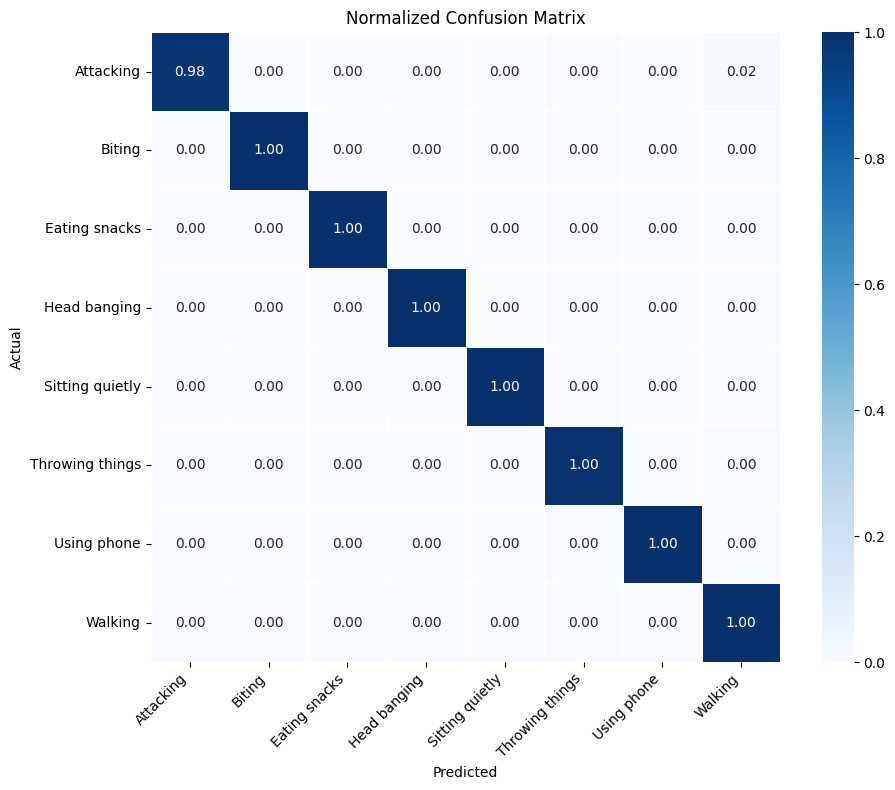

In [28]:
# Evaluate a XGBoost model using the preprocessed dataset.
# 前処理済みデータセットを用いて、XGBoostモデルを評価

hist_gradient = model_hist_gradient()
evaluate_supervised(all_subjects_norm, hist_gradient);